****Imports and Loading Data****

We will load the data and identify the number of observations, predictors, and the target variable as required.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/diabetes.csv")

# Part A: Identify basic dataset properties
print(f"Number of observations: {df.shape[0]}")
print(f"Number of predictors: {df.shape[1] - 1}")
print(f"Target variable: 'Outcome' (0 = No diabetes, 1 = Diabetes)")
print("\nData Types:")
print(df.dtypes)
print("\nClass Distribution:")
print(df["Outcome"].value_counts())

df.head()

Number of observations: 768
Number of predictors: 8
Target variable: 'Outcome' (0 = No diabetes, 1 = Diabetes)

Data Types:
Pregnancies                   int64
Glucose                       int64
BloodPressure               float64
SkinThickness                 int64
Insulin                     float64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

Class Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


****Investigating "Zero" Values****

Our assignment document correctly points out that zero values exist for biological measurements like Glucose, BloodPressure, SkinThickness, Insulin, and BMI. A blood pressure or BMI of 0 is biologically impossible, meaning these are hidden missing values.

In [2]:
# List of columns where a value of 0 is medically impossible
invalid_zero_cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count how many zero values exist in these columns
zero_counts = (df[invalid_zero_cols] == 0).sum()
print("Count of hidden missing values (0s) per column:")
display(zero_counts)

Count of hidden missing values (0s) per column:


Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

****Handling Missing Values (Imputation)****

Instead of deleting all observations with zeros (which would destroy our dataset size), we will replace the 0s with NaN, and then impute them using the median of their respective columns.

In [3]:
# Replace 0s with NaN
df[invalid_zero_cols] = df[invalid_zero_cols].replace(0, np.nan)

# Verify replacement
print("Null values after replacement:")
print(df.isnull().sum())

# Impute missing values using the median
for col in invalid_zero_cols:
    median_val = df[col].median()
    df[col] = df[col].fillna(median_val)

print("\nNull values after median imputation:")
print(df.isnull().sum())

Null values after replacement:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

Null values after median imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


### Justification for Missing Value Treatment

I chose to replace the invalid zero values with the **median** rather than dropping the observations. 

* **Why not drop?** Variables like `Insulin` and `SkinThickness` have hundreds of missing values. Dropping these rows would result in severe data loss, drastically reducing the training size and statistical power of the classification models.
* **Why the median?** Medical data often contains extreme outliers (e.g., abnormally high insulin levels). The median is robust to outliers, whereas the mean would be artificially skewed by these extreme observations.

****Visualizing Relationships****

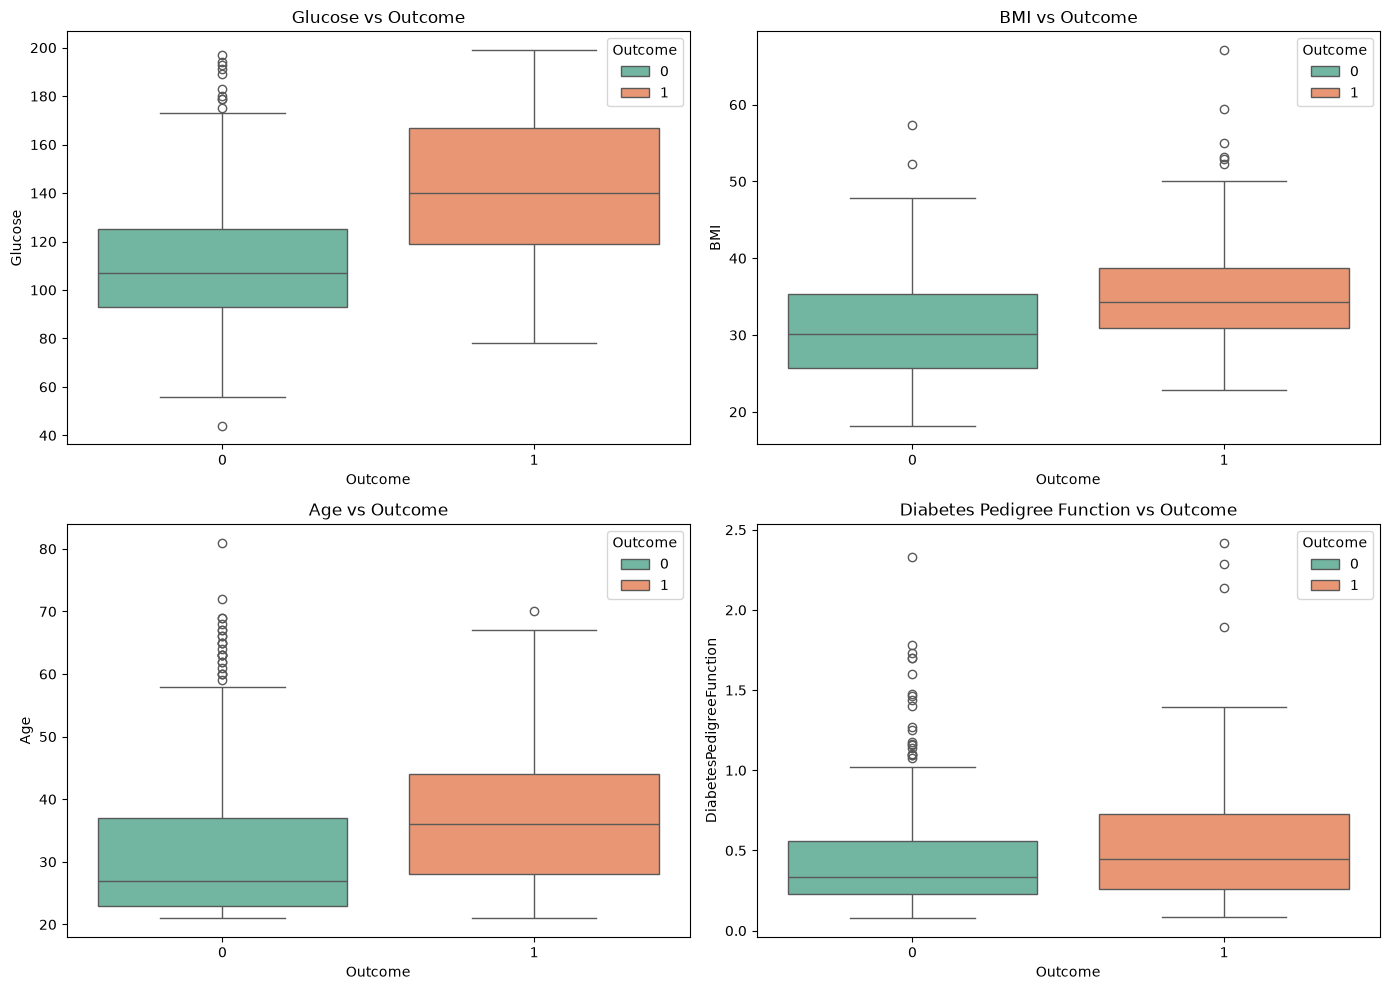

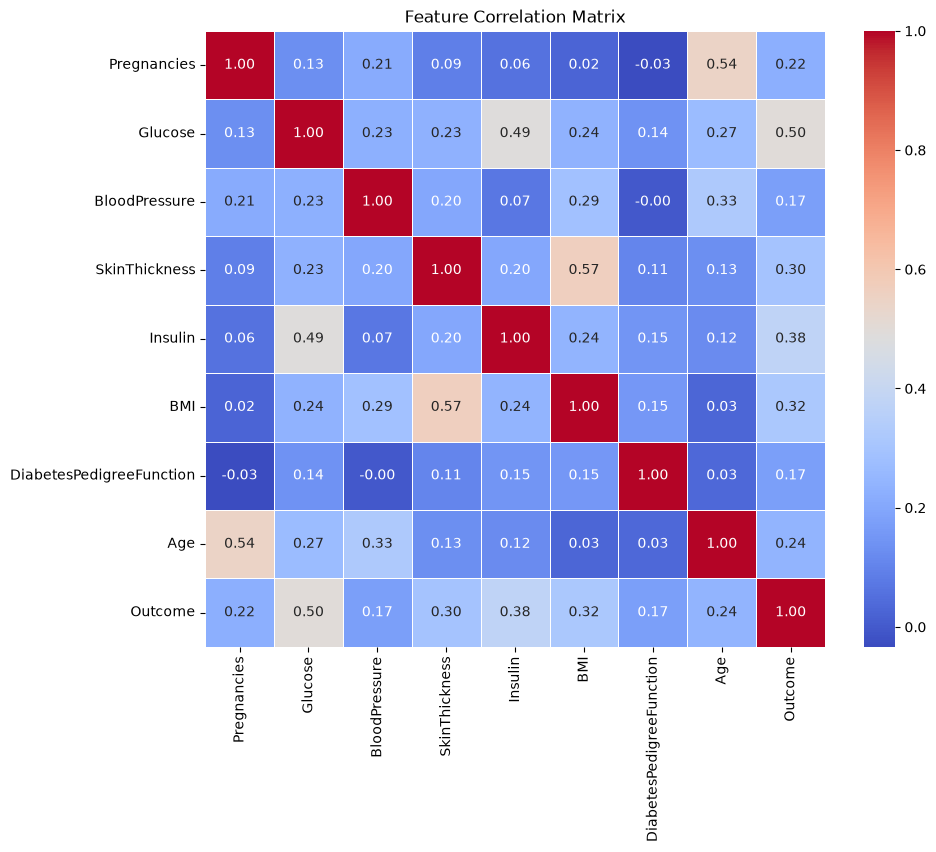

In [4]:
# Set up a grid for multiple plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Glucose vs Outcome
sns.boxplot(x="Outcome", y="Glucose", hue="Outcome", data=df, ax=axes[0, 0], palette="Set2")
axes[0, 0].set_title("Glucose vs Outcome")

# 2. BMI vs Outcome
sns.boxplot(x="Outcome", y="BMI", hue="Outcome", data=df, ax=axes[0, 1], palette="Set2")
axes[0, 1].set_title("BMI vs Outcome")

# 3. Age vs Outcome
sns.boxplot(x="Outcome", y="Age", hue="Outcome", data=df, ax=axes[1, 0], palette="Set2")
axes[1, 0].set_title("Age vs Outcome")

# 4. Diabetes Pedigree Function vs Outcome
sns.boxplot(x="Outcome", y="DiabetesPedigreeFunction", hue="Outcome", data=df, ax=axes[1, 1], palette="Set2")
axes[1, 1].set_title("Diabetes Pedigree Function vs Outcome")

plt.tight_layout()
plt.show()

# 5. Correlation Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Feature Correlation Matrix")
plt.show()

****Answering the EDA Questions****

### Exploratory Data Analysis Insights

#### 1. Which variables appear most strongly associated with diabetes?
Based on the correlation matrix, **Glucose** shows the strongest positive correlation with the outcome (**0.50**), followed by **Insulin** (**0.38**), **BMI** (**0.32**), and **SkinThickness** (**0.30**). The boxplots also show noticeably higher Glucose and BMI values among diabetic patients.

#### 2. Are there variables that appear redundant?
**SkinThickness** and **BMI** (**0.57**), as well as **Pregnancies** and **Age** (**0.54**), show relatively strong positive correlations. This indicates that these pairs share some information, although they are not highly correlated enough to be considered completely redundant.

#### 3. Is the dataset balanced?
**No**, the dataset is imbalanced. There are significantly more non-diabetic observations (Class 0) than diabetic observations (Class 1).

#### 4. Are there extreme observations?
**Yes**, the boxplots reveal several extreme outliers, particularly in **Insulin** and **DiabetesPedigreeFunction**.

#### 5. Do diabetic and non-diabetic patients appear separable?
They are **not perfectly separable**. Although diabetic patients generally have higher Glucose, BMI, and Age values, there is substantial overlap between the two groups. This suggests that no single feature can perfectly distinguish diabetic from non-diabetic patients, so multiple features will likely be needed for prediction.

**(Exporting Cleaned Data)
Save the Preprocessed Data for Modeling**

To ensure our models use the exact same cleaned data without having to rerun the EDA notebook, let's export the preprocessed DataFrame.

In [6]:
# Save the preprocessed dataset to use in the modeling notebook
df.to_csv("../data/diabetes_cleaned.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
